In [26]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import sys
sys.path.insert(0, '/pbabkin/main/mipt/nas-for-moe/code/data')
sys.path.insert(0, '/pbabkin/main/mipt/nas-for-moe/code')
import nas_moe.vae
import nas_moe.dataset
import nas_moe.surrogate
import nas_moe.single_arch
import nas_moe.graph
import nas_moe.utils
import os
from torch.utils.data import DataLoader
from torch_geometric.data import Batch
from pathlib import Path
import torch.nn as nn
from torch.utils.data import DataLoader
from torch_geometric.data import Batch
from tqdm import tqdm
from nni.nas.hub.pytorch import DARTS as DartsSpace
from torch_geometric.utils import dense_to_sparse
import random

SEED = 322
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

: 

In [27]:
train_dataset = torchvision.datasets.CIFAR10(
    root='/pbabkin/main/mipt/nas-for-moe/code/data',
    train=True,
    download=True,
    transform=transforms.ToTensor()
)

split_valid = int(10000)
num_samples = len(train_dataset)
indices = list(range(num_samples))
np.random.seed(42)
np.random.shuffle(indices)
valid_subset = Subset(train_dataset, indices[split_valid:])
valid_labels = [label for im, label in valid_subset]

Files already downloaded and verified


In [28]:
device = 'cuda' if torch.cuda.is_available() else 'cpu'
# model = nas_moe.vae.VAE(latent_dim=128, channel_num=3)
# trainer = nas_moe.vae.VAETrainer(model, device, lr=3e-4, weight_decay=1e-5)
model2 = nas_moe.vae.VAEv2(
    input_channels=3,
    input_size=32,
    filter_sizes=[32, 64, 128],
    latent_dim=64,
    kernel_size=3,
    stride=2,
    padding=1,
    is_variational=True 
)

trainer = nas_moe.vae.VAETrainer(model2, device, lr=2e-4, weight_decay=1e-5)
trainer.load_checkpoint('/pbabkin/main/mipt/nas-for-moe/vae_checkpoint_anton_1.pth')

/pbabkin/main/mipt/nas-for-moe/code/nas_moe/vae.py:521: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  checkpoint = torch.load(path, map_location=self.device)


In [29]:
# Подготовка данных
images = []
labels = []

for img, label in valid_subset:
    if True:
        z = trainer.encode_image(img)  # Получаем латентный вектор (тензор)
        images.append(z.cpu().numpy())  # Переводим в numpy
    else:
        img_array = (img.permute(1, 2, 0).numpy() * 255).astype(np.uint8)
        img_flat = img_array.flatten()
        images.append(img_flat)

    labels.append(label)

X = np.array(images)
y = np.array(labels)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
print(f"Форма данных: {X.shape}")
# 3072 - просто

KeyboardInterrupt: 

In [52]:
N_CLUSTERS = 4
kmeans = KMeans(n_clusters=N_CLUSTERS, random_state=42, n_init=20, verbose=0)
kmeans.fit(X_scaled)

clusters = kmeans.labels_

# Plot clusters

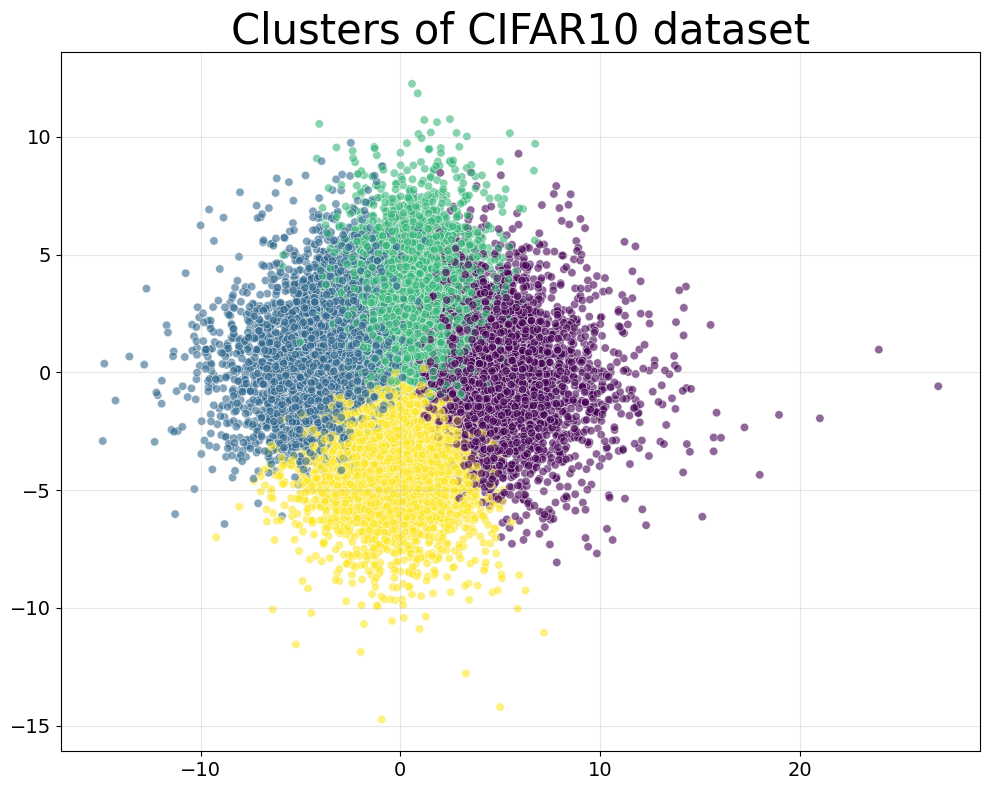

Объясненная дисперсия: 22.22%


In [53]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# PCA для уменьшения размерности до 2D
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Увеличиваем размеры шрифтов
# plt.rcParams.update({'font.size': 40})

# Визуализация кластеров
plt.figure(figsize=(10, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=clusters, cmap='viridis', 
                     alpha=0.6, edgecolors='w', linewidth=0.5)

# Центры кластеров в PCA-пространстве
centers_pca = pca.transform(kmeans.cluster_centers_)

# plt.xlabel(f'PC 1 ({pca.explained_variance_ratio_[0]:.2%} variance)', fontsize=20)
# plt.ylabel(f'PC 2 ({pca.explained_variance_ratio_[1]:.2%} variance)', fontsize=20)
plt.title(f'Clusters of CIFAR10 dataset', fontsize=30)
plt.tick_params(axis='both', which='major', labelsize=14)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Объясненная дисперсия: {pca.explained_variance_ratio_.sum():.2%}")

# Define and Train

In [54]:
base_path = Path('/pbabkin/main/mipt/nas-for-moe/code/data/CIFAR10_acc/trained_models_archs_1')
model_dicts_paths = [base_path / p for p in os.listdir(base_path)]

random.shuffle(model_dicts_paths)

split = int(0.8 * len(model_dicts_paths))
dataset_cluster_acc_train = nas_moe.dataset.ArchClusterACCDataset(
    model_dicts_paths[:split], 
    clusters,
    valid_labels,
    target_cluster='all'
)
dataset_cluster_acc_test = nas_moe.dataset.ArchClusterACCDataset(
    model_dicts_paths[split:], 
    clusters,
    valid_labels,
    target_cluster='all'
)

def collate_graphs(batch):
    return Batch.from_data_list(batch)

train_loader = DataLoader(
    dataset_cluster_acc_train,
    batch_size=32,
    shuffle=True,
    collate_fn=collate_graphs
)

test_loader = DataLoader(
    dataset_cluster_acc_test,
    batch_size=32,
    shuffle=False,
    collate_fn=collate_graphs
)

In [55]:
targets = []
for el in dataset_cluster_acc_train:
    targets.append(el.y)

targets = torch.cat(targets, dim=0)  # Объединить все [1, 10] в [N, 10]
mean_targets_train = targets.mean(dim=0)    # Mean по всем примерам → [10]

print(f"Shape: {mean_targets_train.shape}")
print(f"Mean: {mean_targets_train}")

targets = []
for el in dataset_cluster_acc_test:
    targets.append(el.y)

targets_test = torch.cat(targets, dim=0)

print(targets_test.shape)
print(mean_targets_train.shape)

Shape: torch.Size([4])
Mean: tensor([0.7895, 0.7466, 0.7340, 0.7599])
torch.Size([200, 4])
torch.Size([4])


In [56]:
mse_baseline = ((targets_test - mean_targets_train)**2).mean()
mse_baseline

tensor(6.3463e-05)

In [57]:
surr = nas_moe.surrogate.GAT(8, N_CLUSTERS)

In [59]:
surr.to(device)

history = nas_moe.utils.train_surrogate_with_val(surr, train_loader=train_loader, test_loader=test_loader,
                                       device=device, epochs=170,
                                       lr=0.001, weight_decay=1e-5)
print(history['train'][-1])
print(history['test'][-1])

Training surrogate: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████| 170/170 [13:32<00:00,  4.78s/it]

6.340216306853108e-05
4.790528172244584e-05


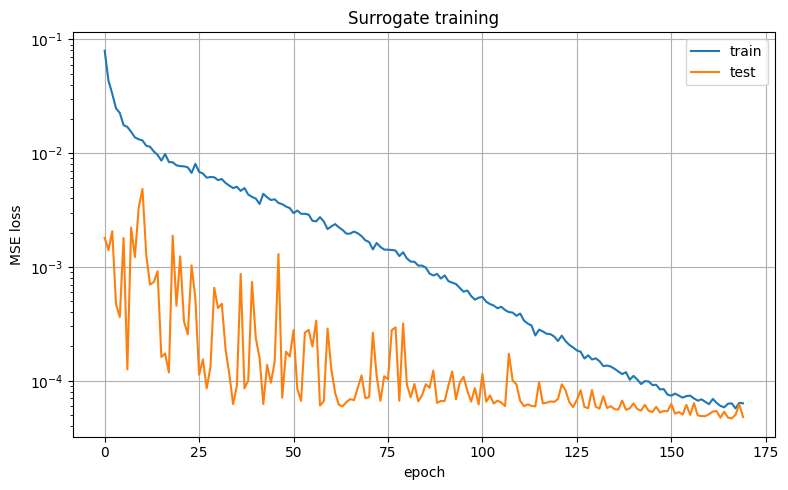

In [60]:
plt.rcParams.update({'font.size': 10})
plt.figure(figsize=(8, 5))
plt.plot(history['train'], label='train')
plt.plot(history['test'], label='test')
plt.xlabel('epoch')
plt.ylabel('MSE loss')
plt.title('Surrogate training')
plt.yscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [61]:
torch.save(surr.state_dict(), '/pbabkin/main/mipt/nas-for-moe/code/surr_model_3.pth')

# Inference

In [62]:
surr = nas_moe.surrogate.GAT(8, N_CLUSTERS)
state_dict = torch.load('/pbabkin/main/mipt/nas-for-moe/code/surr_model_3.pth', map_location=device)
surr.load_state_dict(state_dict, strict=True)
# surr.to(device)
# print('Model ready')

/tmp/ipykernel_280/2888575507.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  state_dict = torch.load('/pbabkin/main/mipt/nas-for-moe/code/surr_model_3.pth', map_locatio

<All keys matched successfully>

In [109]:
from scipy.stats import spearmanr


predictions = []
gt = []
surr.cpu()
surr.eval()
cluster_id = 0
for data in tqdm(dataset_cluster_acc_test):
    # print(data.x, data.edge_index, data.y)
    predictions.append(surr(data.x, data.edge_index, data.batch).detach()[0][cluster_id])
    gt.append(data.y[0][cluster_id])
    # print(predictions[-1][0][0])
    # print(gt[-1][0][0])



corr, pval = spearmanr(gt, predictions)

print(f"Spearman correlation: {corr:.4f}")
print(f"p-value: {pval:.4e}")

100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 200/200 [00:01<00:00, 109.61it/s]

Spearman correlation: 0.5394
p-value: 1.7123e-16


/tmp/ipykernel_280/811616419.py:18: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(fontsize=10)


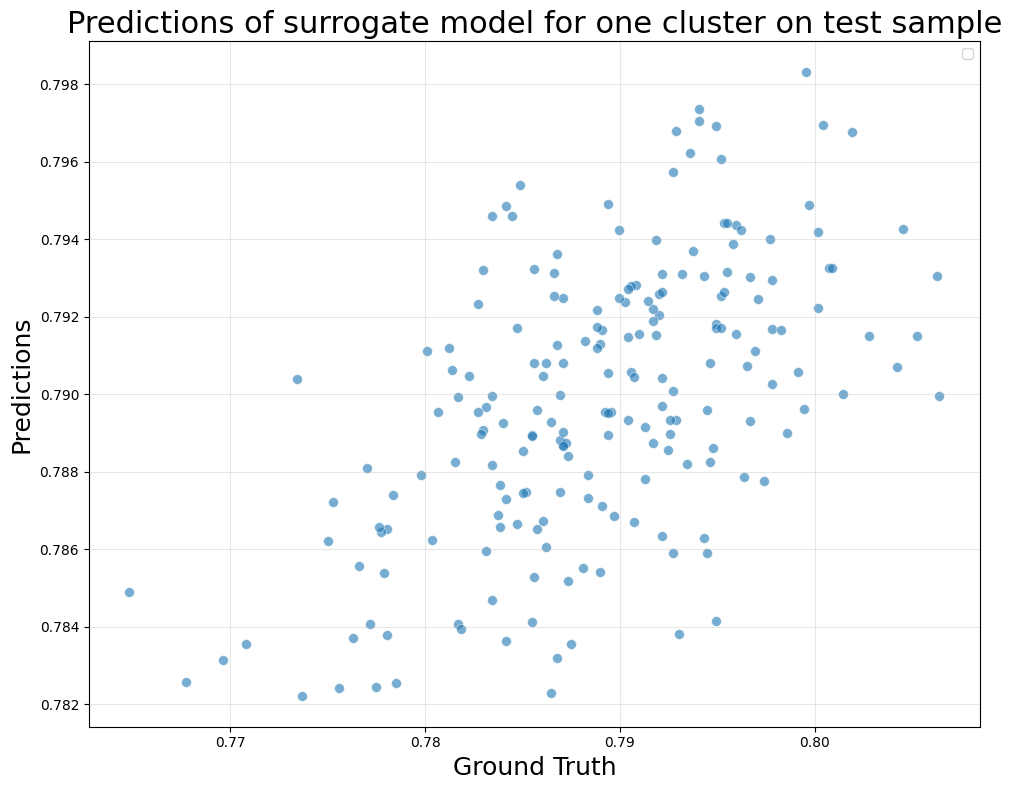

MAE (Mean Absolute Error): 0.0049
RMSE (Root Mean Squared Error): 0.0062
R² Score: 0.2991


In [108]:
predictions = np.array(predictions).flatten()
gt = np.array(gt).flatten()

plt.figure(figsize=(10, 8))

# Основной scatter plot
plt.scatter(gt, predictions, alpha=0.6, s=50, edgecolors='w', linewidth=0.5)

# Диагональная линия идеальных предсказаний
min_val = min(gt.min(), predictions.min())
max_val = max(gt.max(), predictions.max())
# plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='Perfect prediction')

plt.xlabel('Ground Truth', fontsize=18)
plt.ylabel('Predictions', fontsize=18)
plt.title('Predictions of surrogate model for one cluster on test sample', fontsize=22)
plt.grid(True, alpha=0.3)
plt.legend(fontsize=10)
plt.tight_layout()
plt.show()

# Метрики качества
mae = np.mean(np.abs(predictions - gt))
rmse = np.sqrt(np.mean((predictions - gt)**2))
r2 = 1 - (np.sum((predictions - gt)**2) / np.sum((gt - gt.mean())**2))

print(f"MAE (Mean Absolute Error): {mae:.4f}")
print(f"RMSE (Root Mean Squared Error): {rmse:.4f}")
print(f"R² Score: {r2:.4f}")

In [ ]:
cluster_accs = [surr(el.x, ) for el in dataset_cluster_acc_test]

AttributeError: 'GlobalStorage' object has no attribute 'X'

In [ ]:
model_space = DartsSpace(
    width=16,
    num_cells=3,
    dataset='cifar'
)

In [ ]:
arch_dicts = []
archGenerator = nas_moe.single_arch.ParamFilteredArchitectureGenerator(model_space, 8, SEED, threshold=0.7)
# arch_dicts += [archGenerator.generate_arch()['architecture'] for _ in range(10000)]
arch_dicts += [archGenerator.generate_arch_filtered()['architecture'] for _ in tqdm(range(10000))]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [00:36<00:00, 276.50it/s]


Mean parameters count =  39169.4784
Max parameters count =  27732.1856


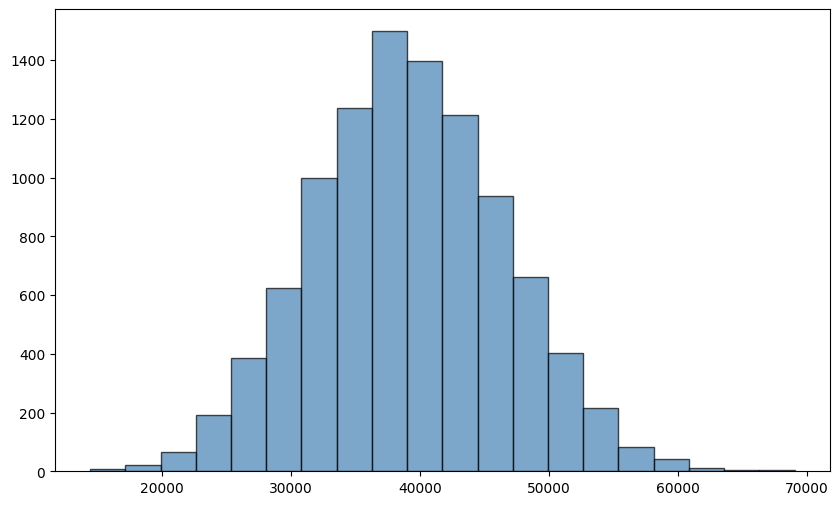

In [ ]:
arch_parameters = []
for a in arch_dicts:
    arch_parameters.append(archGenerator.count_params(a))
print('Mean parameters count = ', sum(arch_parameters) / len(arch_dicts))
print('Max parameters count = ', archGenerator.threshold)
plt.figure(figsize=(10, 6))
plt.hist(arch_parameters, bins=20, color='steelblue', edgecolor='black', alpha=0.7)
plt.show()

In [ ]:
surr.cpu()

def inference_surr(arch):
    graph = nas_moe.graph.Graph(arch, index=0)
    adj, _, features = graph.get_adjacency_matrix()
    
    features = torch.tensor(features, dtype=torch.float)
    adj = torch.tensor(adj, dtype=torch.float)
    
    edge_index, _ = dense_to_sparse(adj)
    
    batch = torch.zeros(features.size(0), dtype=torch.long)
    
    with torch.no_grad():
        output = surr(features, edge_index, batch)
    return output.squeeze(0)

In [ ]:
cluster_accs = [inference_surr(arch) for arch in tqdm(arch_dicts)]

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████| 10000/10000 [01:11<00:00, 140.41it/s]


In [ ]:
stacked = torch.stack(cluster_accs)  # shape (5, 10)

topk_values, topk_indices = torch.topk(stacked, k=3, dim=0)

max_indices = topk_indices[0]

print("max indices:", max_indices)

max indices: tensor([5855, 2917, 8386, 1846, 1461,  836, 2954, 1846, 5855, 1846])


In [ ]:
stacked = torch.stack(cluster_accs)  # shape (5, 10)
max_indices = torch.argmax(stacked, dim=0)  # shape (10,)
print("Max indices:", max_indices)
print("Unique indices:", np.unique(max_indices))
print(len(max_indices), len(np.unique(max_indices)))

Max indices: tensor([9205, 8754, 1565, 6391, 7333])
Unique indices: [1565 6391 7333 8754 9205]
5 5


In [ ]:
for i in np.unique(max_indices):
    print(archGenerator.count_params(arch_dicts[i]))

53248
62368
64736
59776
66304


In [ ]:
import numpy as np
import torch
import torchvision
import torchvision.transforms as transforms
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from torch.utils.data import Subset
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import sys
sys.path.insert(0, '/pbabkin/nas-for-moe/code')
from pathlib import Path

In [ ]:
import nas_moe.graph
import os
import json

In [ ]:
folder_path = Path('./data/CIFAR10_acc/trained_models_archs_1')
json_paths = [Path(x) for x in os.listdir(folder_path)]

FileNotFoundError: [Errno 2] No such file or directory: 'data/CIFAR10_acc/trained_models_archs_1'

In [ ]:
valid_predictions_list = []
valid_acc_list = []
architecture_list = []

for json_path in json_paths:
    with open(folder_path / json_path, 'r') as file:
        data = json.load(file)

    valid_predictions_list += [data['valid_predictions']]
    valid_acc_list += [data['valid_accuracy']]
    architecture_list.append(data['architecture'])
        
    file_path = Path("data.json")

In [ ]:
graph = nas_moe.graph.Graph(architecture_list[0])

In [ ]:
adj_matrix, operations, one_hot_ops = graph.get_adjacency_matrix()

In [ ]:
adj_matrix.shape

(21, 21)

In [ ]:
import torch
torch.cuda.is_available()

In [ ]:
import nas_moe.dataset

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
dataset_cluster_acc = nas_moe.dataset.ArchClusterACCDataset(
    './data/CIFAR10_acc/trained_models_archs_1', 

)

nas_moe.dataset.ArchClusterACCDataset